Data loaded successfully!
  location  year         category  rank  query
0   Global  2001  Consumer Brands     1  Nokia
1   Global  2001  Consumer Brands     2   Sony
2   Global  2001  Consumer Brands     3    BMW
3   Global  2001  Consumer Brands     4   Palm
4   Global  2001  Consumer Brands     5  Adobe


/tmp/ipykernel_1216/3507932855.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2, 1].boxplot(data_by_cat, labels=top_cats)


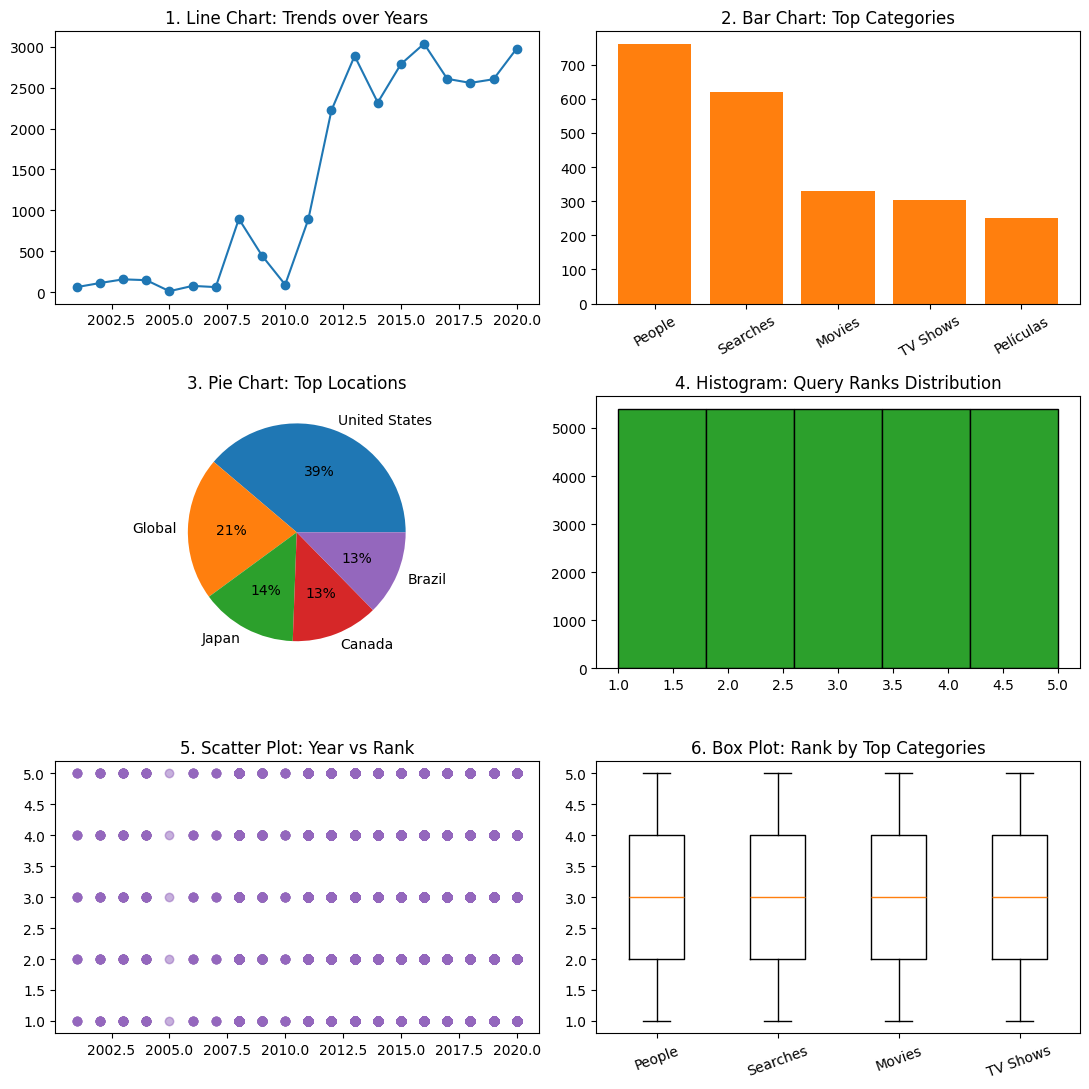

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Directly import Kaggle Google Trends CSV from hosted URL
url = "https://raw.githubusercontent.com/tttdddnet/Python-Data-Journalism/main/part1/trends.csv"
df = pd.read_csv(url)

# Print first few rows to confirm columns: ['location', 'year', 'category', 'rank', 'query']
print("Data loaded successfully!")
print(df.head())

# 2. Setup Plot Grid (3 rows x 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(11, 11))

# --- CHART 1: LINE CHART ---
year_counts = df["year"].value_counts().sort_index()
axes[0, 0].plot(
    year_counts.index, year_counts.values, marker="o", color="tab:blue"
)
axes[0, 0].set_title("1. Line Chart: Trends over Years")

# --- CHART 2: BAR CHART ---
cat_counts = df["category"].value_counts().head(5)
axes[0, 1].bar(cat_counts.index, cat_counts.values, color="tab:orange")
axes[0, 1].set_title("2. Bar Chart: Top Categories")
axes[0, 1].tick_params(axis="x", rotation=30)

# --- CHART 3: PIE CHART ---
loc_counts = df["location"].value_counts().head(5)
axes[1, 0].pie(loc_counts, labels=loc_counts.index, autopct="%1.0f%%")
axes[1, 0].set_title("3. Pie Chart: Top Locations")

# --- CHART 4: HISTOGRAM ---
axes[1, 1].hist(df["rank"], bins=5, color="tab:green", edgecolor="black")
axes[1, 1].set_title("4. Histogram: Query Ranks Distribution")

# --- CHART 5: SCATTER PLOT ---
axes[2, 0].scatter(df["year"], df["rank"], color="tab:purple", alpha=0.3)
axes[2, 0].set_title("5. Scatter Plot: Year vs Rank")

# --- CHART 6: BOX PLOT ---
top_cats = df["category"].value_counts().head(4).index
data_by_cat = [df[df["category"] == c]["rank"] for c in top_cats]
axes[2, 1].boxplot(data_by_cat, labels=top_cats)
axes[2, 1].set_title("6. Box Plot: Rank by Top Categories")
axes[2, 1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()